# Roulette Simulation and Profit Analysis

## Q1

In [1]:
import random

def roulette(N,Bet):
    total_earnings = 0
    
    for _ in range(N):
        outcome = random.randint(1, 38)
        
        if 1 <= outcome <= 18:
            total_earnings += Bet
        else:
            total_earnings -= Bet
    
    return total_earnings
Bet = 1
N = 1000
print(f"SN =  {roulette(N,Bet)} $")


SN =  -52 $


## Q2

Using Monte Carlo simulation to study the distribution of total earnings Sn.

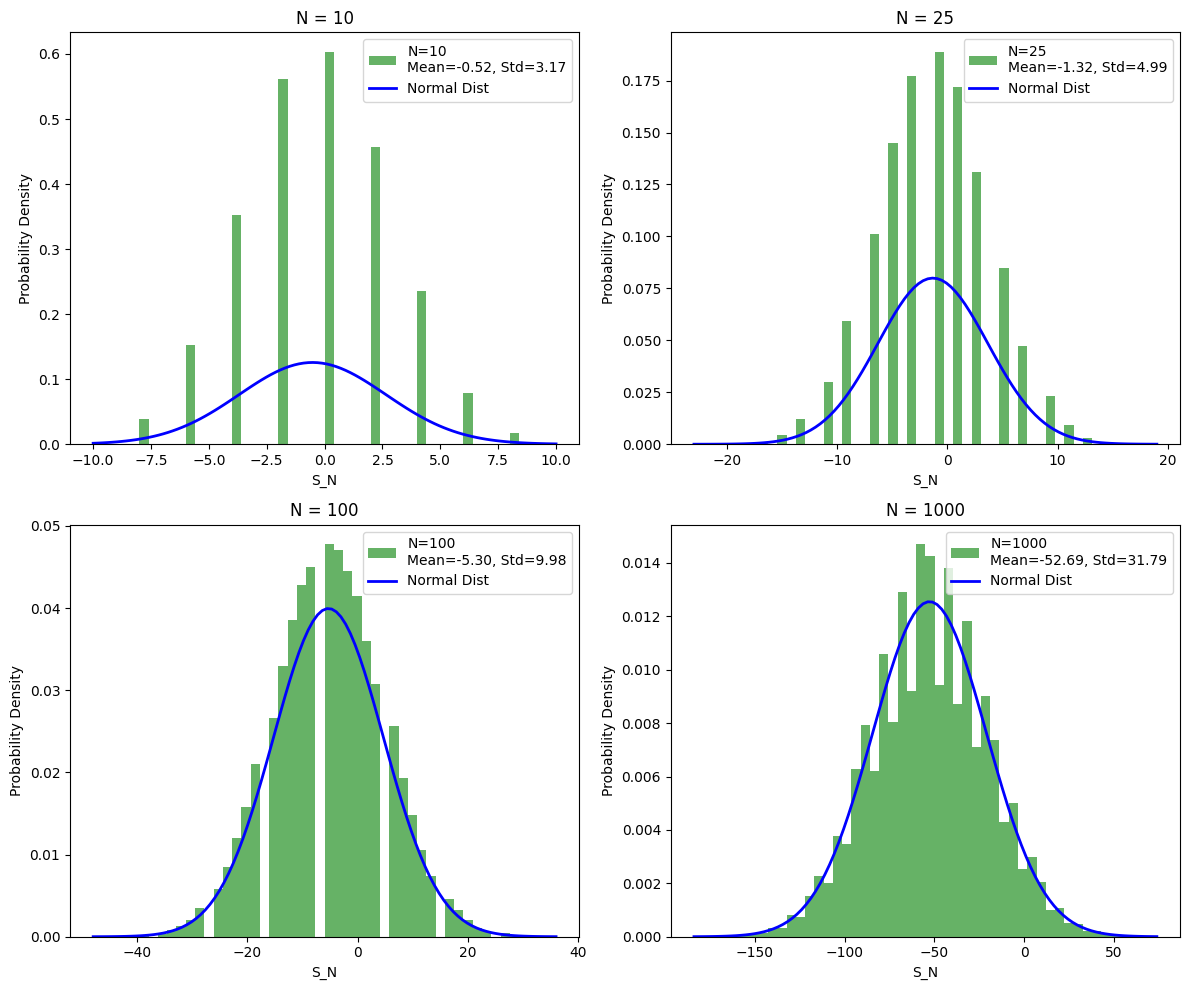

N=10: Expected Value = -0.5228, Std = 3.1739 , Standard Error =  0.0100
N=25: Expected Value = -1.3232, Std = 4.9908 , Standard Error =  0.0158
N=100: Expected Value = -5.3025, Std = 9.9847 , Standard Error =  0.0316
N=1000: Expected Value = -52.6930, Std = 31.7879 , Standard Error =  0.1005


In [2]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats

def roulette(N, Bet):
    outcomes = np.random.randint(1, 39, size=N)
    total_earnings = np.where(outcomes <= 18, Bet, -Bet).sum()
    return total_earnings

def monte_carlo(N, Bet, simulations):
    results = [roulette(N, Bet) for _ in range(simulations)]
    return results

def plot_distribution(N_values, Bet, simulations):
    plt.figure(figsize=(12, 10))
    results_list = []
    
    for i, N in enumerate(N_values):
        results = monte_carlo(N, Bet, simulations)
        results_list.append(results)
        mean = np.mean(results)
        std_dev = np.std(results)
        
        plt.subplot(2, 2, i+1)
        plt.hist(results, bins=50, density=True, alpha=0.6, color='g', label=f'N={N}\nMean={mean:.2f}, Std={std_dev:.2f}')
        
        x = np.linspace(min(results), max(results), 100)
        plt.plot(x, stats.norm.pdf(x, mean, std_dev), 'b', linewidth=2, label='Normal Dist')
        
        plt.xlabel("S_N")
        plt.ylabel("Probability Density")
        plt.legend()
        plt.title(f"N = {N}")
    
    plt.tight_layout()
    plt.show()

    for i, N in enumerate(N_values):
        results = results_list[i]
        expected_value = np.mean(results)
        std = np.std(results) 
        standard_Error = np.std(results) /  np.sqrt(simulations)

        print(f"N={N}: Expected Value = {expected_value:.4f}, Std = {std:.4f} , Standard Error =  {standard_Error:.4f}" )

Bet = 1
simulations = 100000
N_values = [10, 25, 100, 1000]
plot_distribution(N_values, Bet,simulations)


## Q3

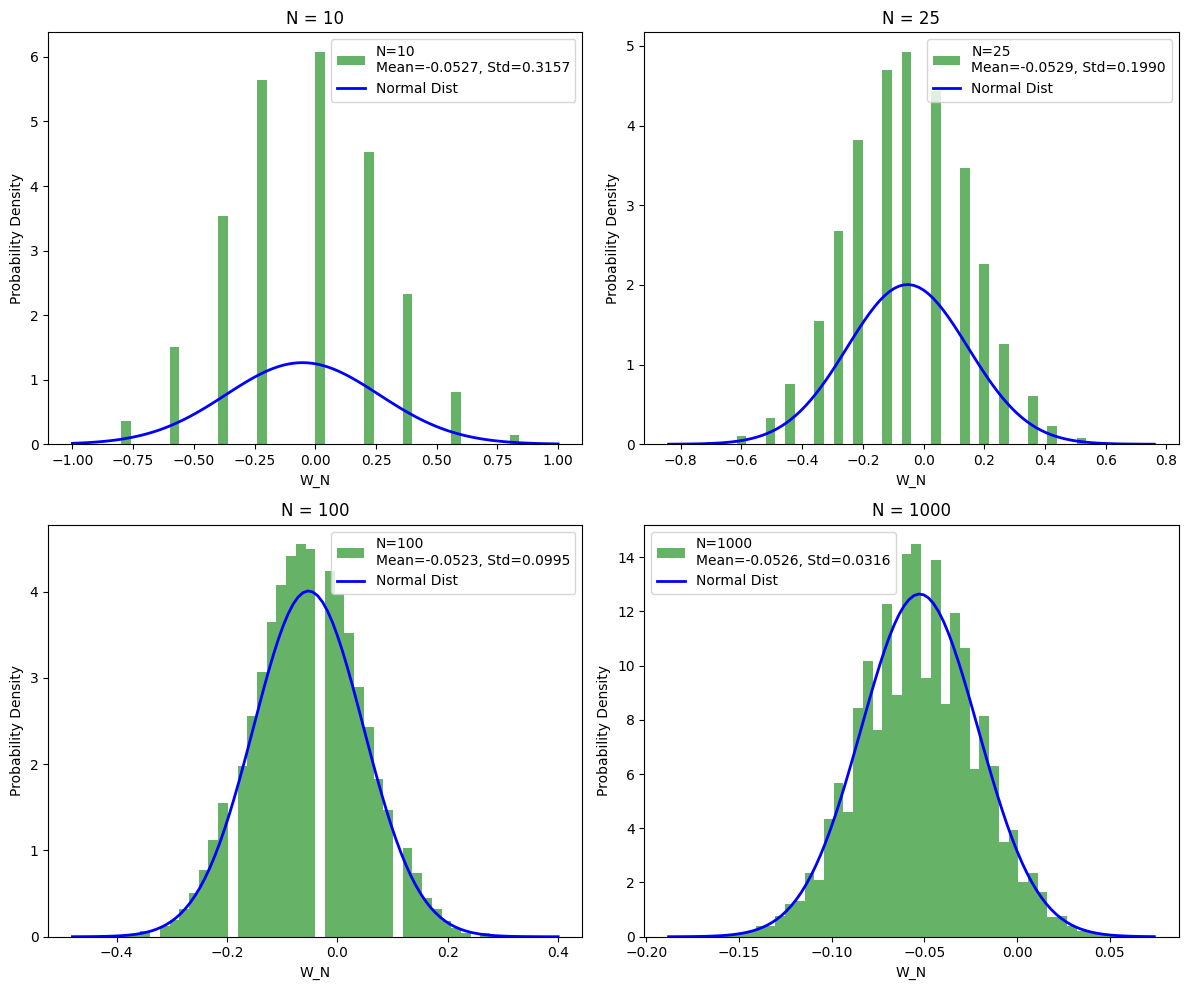

N=10: Expected Value = -0.05275, Standard Error = 0.00100
N=25: Expected Value = -0.05288, Standard Error = 0.00063
N=100: Expected Value = -0.05228, Standard Error = 0.00031
N=1000: Expected Value = -0.05261, Standard Error = 0.00010


In [3]:
def roulette_(N, Bet):
    outcomes = np.random.randint(1, 39, size=N)
    total_earnings = np.where(outcomes <= 18, Bet, -Bet).sum()
    return total_earnings / N 

def monte_carlo(N, Bet, simulations):
    results = [roulette_(N, Bet) for _ in range(simulations)]
    return results

def plot_distribution(N_values, Bet, simulations):
    plt.figure(figsize=(12, 10))
    results_list = []
    
    for i, N in enumerate(N_values):
        results = monte_carlo(N, Bet, simulations)
        results_list.append(results)
        mean = np.mean(results)
        std_dev = np.std(results)
        
        plt.subplot(2, 2, i+1)
        plt.hist(results, bins=50, density=True, alpha=0.6, color='g', 
                 label=f'N={N}\nMean={mean:.4f}, Std={std_dev:.4f}')
        
        x = np.linspace(min(results), max(results), 100)
        plt.plot(x, stats.norm.pdf(x, mean, std_dev), 'b', linewidth=2, label='Normal Dist')
        
        plt.xlabel("W_N")
        plt.ylabel("Probability Density")
        plt.legend()
        plt.title(f"N = {N}")
    
    plt.tight_layout()
    plt.show()

    for i, N in enumerate(N_values):
        results = results_list[i]
        expected_value = np.mean(results)
        standard_error = np.std(results) / np.sqrt(simulations)
        print(f"N={N}: Expected Value = {expected_value:.5f}, Standard Error = {standard_error:.5f}")

Bet = 1
simulations = 100000
N_values = [10, 25, 100, 1000]
plot_distribution(N_values, Bet,simulations)



## Q4

**Expected Value :**
$$
E[X_i] = (1) \times \frac{9}{19} + (-1) \times \frac{10}{19} = \frac{9}{19} - \frac{10}{19} = -\frac{1}{19} \
$$


$$
\text{E}[S_N]=  N \times E[X_i] = -\frac{N}{19} \
$$

$$
for N = 10 :  E[X_i] = -\frac{10}{19}  \approx −0.5263
$$

$$
for N = 25 :  E[X_i] = -\frac{25}{19}  \approx −1.3158
$$

$$
for N = 100 :  E[X_i] = -\frac{100}{19}  \approx −5.2632
$$

$$
for N = 1000 :  E[X_i] = -\frac{1000}{19}  \approx −52.6316
$$


**Standard Error :**
$$
\text{Var}(X_i) = E[X_i^2] - (E[X_i])^2
$$
$$
E[X_i^2] = (1)^2 \times \frac{9}{19} + (-1)^2 \times \frac{10}{19} = 1
$$
$$
\text{Var}(X_i) = 1 - \left(-\frac{1}{19}\right)^2 = \frac{360}{361}
$$

$$
\text{Var}(S_N) = N \times\text{Var}(X_i)  = \frac{360}{361} \cdot N 
$$
$$
\sigma =\sqrt{\text{Var}(S_N)} = \sqrt {\frac{360}{361} \cdot N }
$$

$$
\text{SE}(S_N) = \frac{\sigma}{\sqrt{Number of simulation}} = \frac{\sqrt{\frac{360}{361}\cdot N}}{\sqrt{100000}}
$$

$$
for N = 10 : SE  = \frac{\sqrt{\frac{360}{361} \cdot 10 }}{\sqrt{100000}} \approx 0.00998
$$

$$
for N = 25 : SE  = \frac{\sqrt{\frac{360}{361} \cdot 25 }}{\sqrt{100000}} \approx 0.01578
$$
$$
for N = 100 : SE  = \frac{\sqrt{\frac{360}{361} \cdot 100 }}{\sqrt{100000}} \approx 0.03157
$$
$$
for N = 1000 : SE  = \frac{\sqrt{\frac{360}{361} \cdot 1000 }}{\sqrt{100000}} \approx 0.09986
$$

**The simulated standard error values closely match the theoretical predictions, confirming the accuracy of our Monte Carlo simulation. Any minor discrepancies can be attributed to statistical noise due to a finite number of trials**

## Q5

**Using standardization of the normal distribution:**
$$
\text{Z} = \frac{\text{S}_N - \text{E}[S_N] }{\sigma_{SN}}
$$
$$
P(S_{25} > 0) = P(Z > \frac{0 -(-1.315)}{4.995}) = P(Z > 0.2634)
$$

In [4]:

def clt(N, Bet):
    Ex = -1/19  
    var_X = 360/361  
    Esn = N * Ex
    sigma_S_N = np.sqrt(N * var_X)
    z_score = (0 - Esn) / sigma_S_N
    probability = 1 - stats.norm.cdf(z_score)  # P(Z > 0.2634) = 1 - (Z < 0.2634)
    
    return probability

def monte_carlo(N, Bet, simulations=100000):
    results = np.array([np.sum(np.where(np.random.randint(1, 39, size=N) <= 18, Bet, -Bet)) for _ in range(simulations)])
    probability = np.mean(results > 0)  # P(S_N > 0)
    
    return probability

Bet = 1
N = 25
print(f"CLT Probability: {clt(N, Bet):.4f}")
print(f"Monte Carlo Probability: {monte_carlo(N, Bet):.4f}")

CLT Probability: 0.3961
Monte Carlo Probability: 0.3942


If the Monte Carlo result closely matches the CLT approximation, it confirms that CLT provides a good estimate for this problem!


## Q6

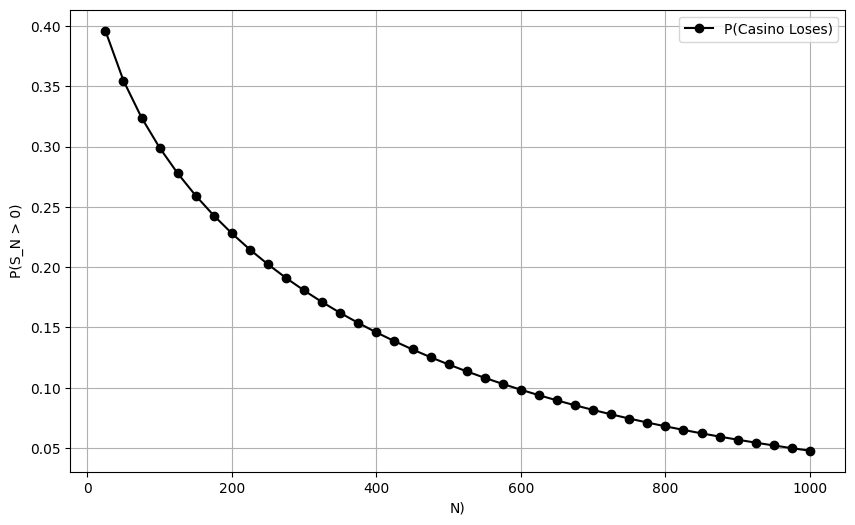

In [5]:

def clt(N, Bet=1):
    E_X = -1/19 
    var_X = 360/361

    E_S_N = N * E_X
    sigma_S_N = np.sqrt(N * var_X)

    z_score = (0 - E_S_N) / sigma_S_N  # Standardized Z-score
    probability = 1 - stats.norm.cdf(z_score)  # P(Z > z_score)
    
    return probability

N_values = np.arange(25, 1001, 25)
probabilities = [clt(N) for N in N_values]

plt.figure(figsize=(10, 6))
plt.plot(N_values, probabilities, marker='o', linestyle='-', color='k', label='P(Casino Loses)')
plt.xlabel("N)")
plt.ylabel("P(S_N > 0)")
plt.legend()
plt.grid()
plt.show()


As the number of games increases, the probability of the casino losing decreases. According to the central limit, the sum of a player's losses or gains converges towards its mean value over a large number of games, whose expected value is negative